# Trabalho de Inteligência Artificial - CNN para GTSRB

## Arquitetura alternativa: VGG-Like Pequena

### 1. Setup

In [2]:
#!/usr/bin/env python3
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

figs_path = '/content/checkpoints'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

Using device: cuda


### 2. Funções de treino e avaliação

In [12]:
def train(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def predict(loader,model,device):
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)

    ytrue = np.concatenate(ytrue)
    ypred = np.concatenate(ypred)

    return ytrue, ypred

def get_confusion_matrix(loader,model,device,num_class=43) -> torch.Tensor:
  cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def per_class_accuracy(y_true, y_pred, num_classes=43) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        if total > 0:
            accs[c] = float((y_pred[mask] == c).sum()) / total
        else:
            accs[c] = float('nan')
    return accs

### 3. Funções de salvamento e carregamento de modelos

In [4]:
def save_model(model,file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  torch.save(model.state_dict(),PATH)
  return PATH

def load_model(file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  model = SmallVGGNet()
  model.load_state_dict(torch.load(PATH))
  return model

### 4. Criando Classe para Rede Neural VGGNet

In [5]:
class SmallVGGNet(nn.Module):
    def __init__(self,img_size=32,num_classes=43):
        super(SmallVGGNet, self).__init__()
        """
        Versão miniaturizada da VGGNet-11 com apenas 3 blocos convolucionais e 2 FC.
        """
        # Bloco 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,32, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 2
        self.conv3 = nn.Conv2d(32,64, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64,64, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 3
        self.conv5 = nn.Conv2d(64,128, kernel_size=3, padding='same')
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128,128, kernel_size=3, padding='same')
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.5)

        # Camadas Lineares
        spatial = img_size // 8
        self.fc1 = nn.Linear(spatial * spatial * 128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn5(self.conv5(x)))
        x = torch.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = torch.flatten(x,1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### 4. Hiperparâmetros e Carregamento dos Dados

In [16]:
# 1) Hiperparâmetros
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 0.001
MOMENTUM = 0.9

# 1.1) Dados — o split ja vem fixo, basta chamar:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

### 5. Função de Treino para Experimento

In [29]:
def run_experiment(name, build_optimizer, device, num_epochs=NUM_EPOCHS):
  model = SmallVGGNet().to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = build_optimizer(model)

  best_val_acc = 0.0
  best_model = None
  best_epoch = 0
  history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

  print(f"Optimizer: {name}\n")

  for epoch in range(num_epochs):
    train_loss, train_acc = train(train_loader, model, criterion, optimizer, device)
    val_loss, val_acc = validate(val_loader, model, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_epoch = epoch + 1
      best_model = model

    print(f'Epoch {(epoch+1):02d}/{num_epochs} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')


  print(f'\nMelhor acurácia de validação: {best_val_acc:.4f} (epoch {best_epoch})')
  checkpoint_path = save_model(best_model,f'{name}_best_model.pth')

  return {
      "name": name,
      "model": best_model,
      "history": history,
      "checkpoint_path": checkpoint_path,
      "best_val_acc": best_val_acc,
      "best_epoch": best_epoch
  }


### 6. Treino

In [34]:
# Treinando modelo com sgd
res_vgg = run_experiment(
    'VGGNet',
    lambda model: optim.Adam(model.parameters(), lr=LR),
    device
)

Optimizer: VGGNet

Epoch 01/30 - Train Loss: 1.7393 - Train Acc: 0.5045 - Val Loss: 0.4050 - Val Acc: 0.8801
Epoch 02/30 - Train Loss: 0.1939 - Train Acc: 0.9461 - Val Loss: 0.1074 - Val Acc: 0.9707
Epoch 03/30 - Train Loss: 0.0695 - Train Acc: 0.9814 - Val Loss: 0.0575 - Val Acc: 0.9846
Epoch 04/30 - Train Loss: 0.0439 - Train Acc: 0.9878 - Val Loss: 0.0568 - Val Acc: 0.9837
Epoch 05/30 - Train Loss: 0.0292 - Train Acc: 0.9921 - Val Loss: 0.0405 - Val Acc: 0.9886
Epoch 06/30 - Train Loss: 0.0222 - Train Acc: 0.9934 - Val Loss: 0.0451 - Val Acc: 0.9895
Epoch 07/30 - Train Loss: 0.0232 - Train Acc: 0.9931 - Val Loss: 0.0406 - Val Acc: 0.9886
Epoch 08/30 - Train Loss: 0.0259 - Train Acc: 0.9926 - Val Loss: 0.0245 - Val Acc: 0.9925
Epoch 09/30 - Train Loss: 0.0164 - Train Acc: 0.9950 - Val Loss: 0.0463 - Val Acc: 0.9889
Epoch 10/30 - Train Loss: 0.0174 - Train Acc: 0.9941 - Val Loss: 0.0216 - Val Acc: 0.9938
Epoch 11/30 - Train Loss: 0.0225 - Train Acc: 0.9930 - Val Loss: 0.0387 - Val Acc

In [40]:
all_results = {"vgg": res_vgg}

to_save = {
    name: {k: v for k, v in r.items() if k not in ["ckpt_path", "model"]}
    for name, r in all_results.items()
}

with open("checkpoints/exp6-1_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp6-1_summary.json")

Resumo salvo em checkpoints/exp6-1_summary.json


### 7. Comparando Curvas de Treino

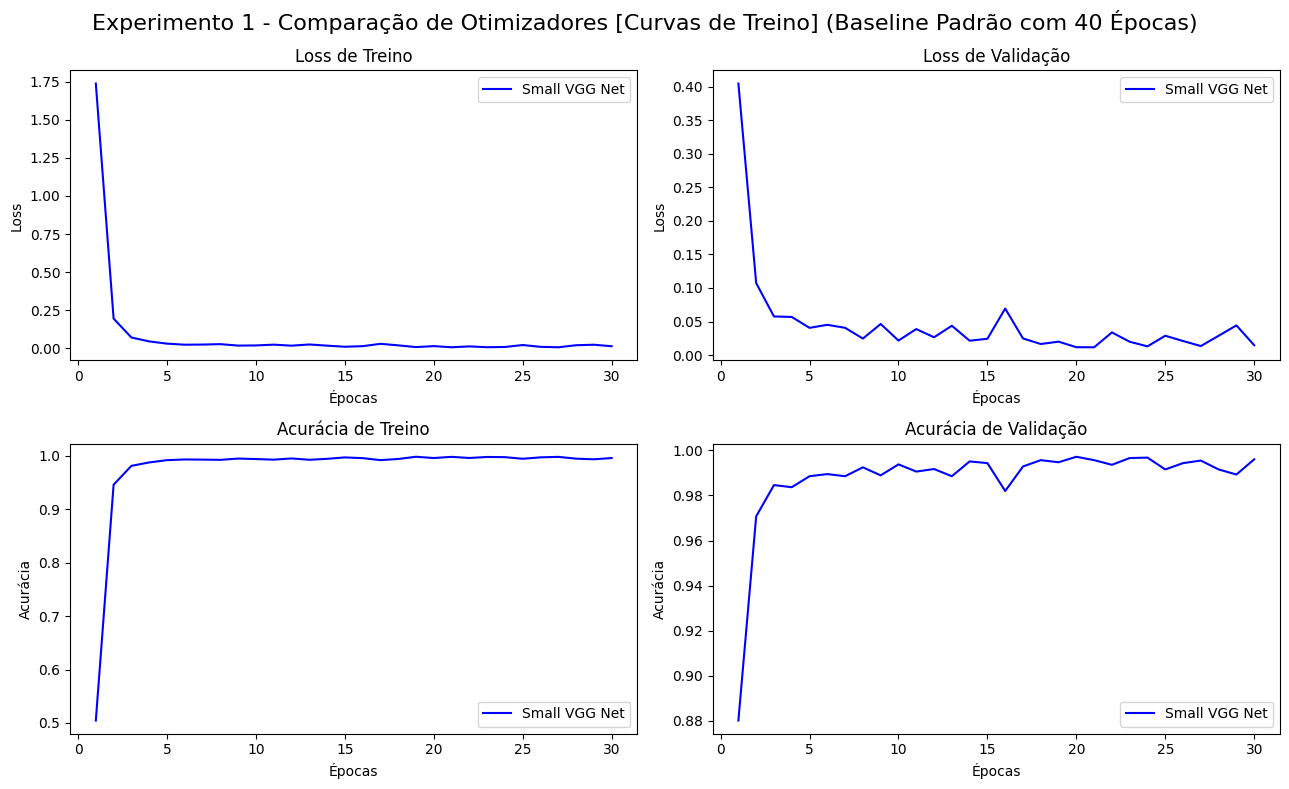

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)
colors = {'vgg': 'blue'}
labels = {'vgg': 'Small VGG Net'}

for name, r in all_results.items():
    axes[0,0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
    axes[0,0].set_title("Loss de Treino")
    axes[0,0].set_xlabel("Épocas")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].legend()

for name, r in all_results.items():
    axes[0,1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
    axes[0,1].set_title("Loss de Validação")
    axes[0,1].set_xlabel("Épocas")
    axes[0,1].set_ylabel("Loss")
    axes[0,1].legend()

for name, r in all_results.items():
    axes[1,0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
    axes[1,0].set_title("Acurácia de Treino")
    axes[1,0].set_xlabel("Épocas")
    axes[1,0].set_ylabel("Acurácia")
    axes[1,0].legend()

for name, r in all_results.items():
    axes[1,1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
    axes[1,1].set_title("Acurácia de Validação")
    axes[1,1].set_xlabel("Épocas")
    axes[1,1].set_ylabel("Acurácia")
    axes[1,1].legend()

plt.suptitle("Experimento 1 - Comparação de Otimizadores [Curvas de Treino] (Baseline Padrão com 40 Épocas)", fontsize=16)
plt.tight_layout()
plt.savefig("figs/exp6-1_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 8. Avaliando Resultados no Conjunto de Teste

In [37]:
metrics_results = {}

for name, r in all_results.items():
    model = SmallVGGNet().to(device)
    model.load_state_dict(torch.load(r["checkpoint_path"]))
    model.eval()
    ytrue, ypred = predict(val_loader, model, device)

    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    metrics_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc
    }

    print(f"{name}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro: {macro_acc:.4f}\n")

vgg:
  Acurácia Global: 0.9842
  Acurácia Macro: 0.9753



### 9. Comparando Matriz de Confusão

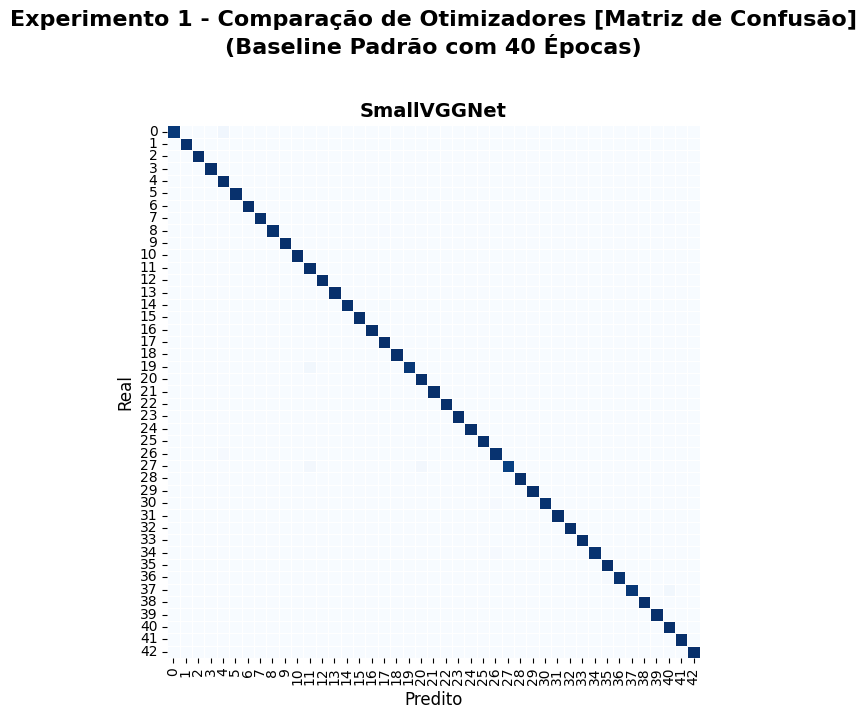

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(22, 7))

cm = {k: get_confusion_matrix(val_loader, r["model"], device).cpu().numpy() for k, r in all_results.items()}
labels = {"vgg": "SmallVGGNet"}

for i, (name, r) in enumerate(all_results.items()):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=False,
        xticklabels=np.arange(NUM_CLASSES),
        yticklabels=np.arange(NUM_CLASSES),
        ax=axes,
        cmap="Blues",
        cbar=i == 2,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="white",
        square=True,
    )
    axes.set_title(f"{labels[name]}", fontsize=14, fontweight="bold")
    axes.set_xlabel("Predito", fontsize=12)
    axes.set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes.tick_params(labelsize=10)

plt.suptitle(
    "Experimento 1 - Comparação de Otimizadores [Matriz de Confusão]\n(Baseline Padrão com 40 Épocas)",
    fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figs/exp6-1_cm.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. Comparando Acurácia por Classe

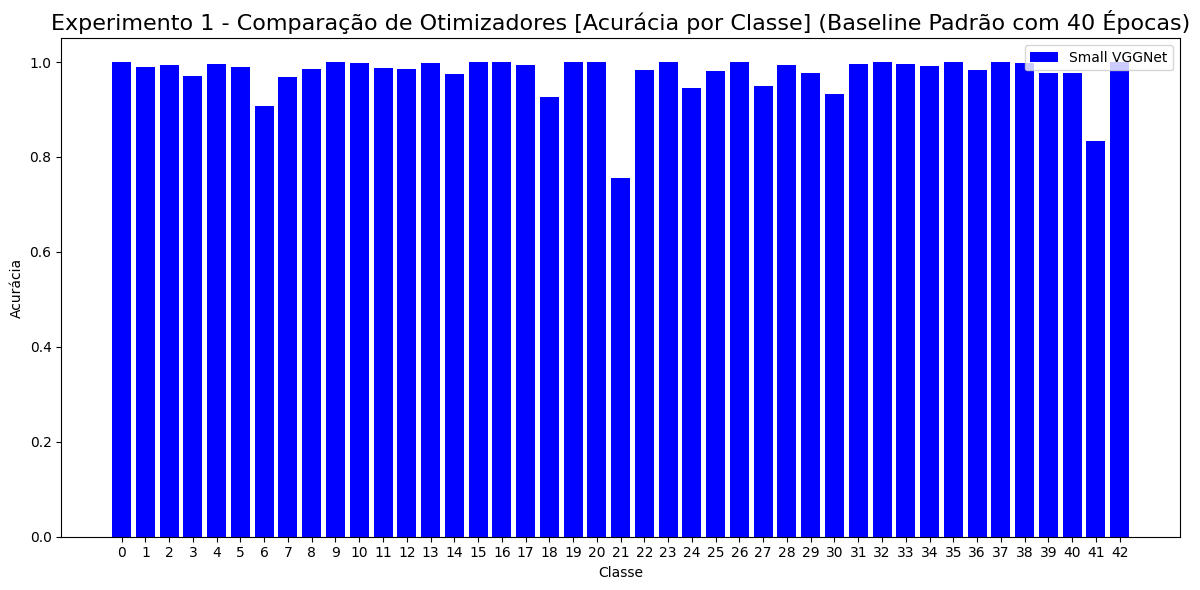

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
labels = {"vgg": "Small VGGNet"}
colors = {"vgg": "blue"}
n_series = len(metrics_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(metrics_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(
        x + offset,
        r["per_class_acc"],
        width=width,
        label=labels[name],
        color=colors[name]
    )

    ax.set_xlabel("Classe")
    ax.set_ylabel("Acurácia")
    ax.set_title("Experimento 1 - Comparação de Otimizadores [Acurácia por Classe] (Baseline Padrão com 40 Épocas)", fontsize=16)
    ax.set_xticks(x)
    ax.legend()

plt.tight_layout()
plt.savefig("figs/exp6-1_acc_by_class.png", dpi=150, bbox_inches="tight")
plt.show()